In [1]:
!pip install -U wandb ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 75.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.8 MB/s eta 0:00:00
  Attempting uninstall: wandb
    Found existing installation: wandb 0.18.3
    Uninstalling wandb-0.18.3:
      Successfully uninstalled wandb-0.18.3


In [2]:
!pip install --upgrade wandb -q


In [3]:
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split
import yaml
from ultralytics import YOLO
import torch
import wandb
import os
import random
import matplotlib.pyplot as plt
import cv2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
os.environ["WANDB_API_KEY"] = "b8a987aa424544e154d91b23556178326e42aa14"

In [5]:
source_images = '/kaggle/input/vehicle-detection-8-classes-object-detection/train/images'
source_labels = '/kaggle/input/vehicle-detection-8-classes-object-detection/train/labels'
destination_root = '/kaggle/working/dataset'

os.makedirs(os.path.join(destination_root, 'train/images'), exist_ok=True)
os.makedirs(os.path.join(destination_root, 'train/labels'), exist_ok=True)
os.makedirs(os.path.join(destination_root, 'test/images'), exist_ok=True)
os.makedirs(os.path.join(destination_root, 'test/labels'), exist_ok=True)

images = [f for f in os.listdir(source_images) if f.endswith('.jpg')]
labels = [f.replace('.jpg', '.txt') for f in images]

train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)

for img, lbl in zip(train_images, train_labels):
    shutil.copy(os.path.join(source_images, img), os.path.join(destination_root, 'train/images', img))
    shutil.copy(os.path.join(source_labels, lbl), os.path.join(destination_root, 'train/labels', lbl))

for img, lbl in zip(test_images, test_labels):
    shutil.copy(os.path.join(source_images, img), os.path.join(destination_root, 'test/images', img))
    shutil.copy(os.path.join(source_labels, lbl), os.path.join(destination_root, 'test/labels', lbl))

In [6]:
data_yaml = {
    'train': '/kaggle/working/dataset/train/images',
    'val': '/kaggle/working/dataset/test/images',
    'nc': 8,
    'names': ['auto', 'bus', 'car', 'lcv', 'motorcycle', 'multiaxle', 'tractor', 'truck']
}

with open('/kaggle/working/dataset/data.yaml', 'w') as file:
    yaml.dump(data_yaml, file, default_flow_style=False)


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [8]:
model = YOLO("yolov8n.pt")

model.train(
    data='/kaggle/working/dataset/data.yaml',
    epochs=30,
    batch=16,
    imgsz=640,
    device=device,   
    project="vehicle-detection",
    name="yolov8n-8classes",
    verbose=True,     
)

Ultralytics 8.4.9 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n-8classes, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspec

2026-02-01 13:44:42,035	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-02-01 13:44:42,843	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=8

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7efeffd90d90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,


image 1/1 /kaggle/working/dataset/test/images/highway_3272_2020-08-26.jpg: 640x640 1 lcv, 1 motorcycle, 1 truck, 6.3ms
Speed: 1.6ms preprocess, 6.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/dataset/test/images/Highway_986_2020-07-30_jpg.rf.589f319dbe93f5ecbacd2a615707c9b6.jpg: 640x640 3 cars, 4 motorcycles, 7.2ms
Speed: 3.0ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/dataset/test/images/highway_2971_2020-08-26.jpg: 640x640 2 cars, 1 truck, 6.3ms
Speed: 2.2ms preprocess, 6.3ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/dataset/test/images/ulu2614_jpg.rf.2cf3fc54c33d46aa3f0d446ce981b9ad.jpg: 640x640 1 bus, 1 car, 1 motorcycle, 1 truck, 6.0ms
Speed: 2.2ms preprocess, 6.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/dataset/test/images/ulu2608_jpg.rf.8f0d23f0b654b5b1a547420b

/tmp/ipykernel_32/3599312123.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  conf = float(pred.conf.cpu().numpy())
/tmp/ipykernel_32/3599312123.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_id = int(pred.cls.cpu().numpy())


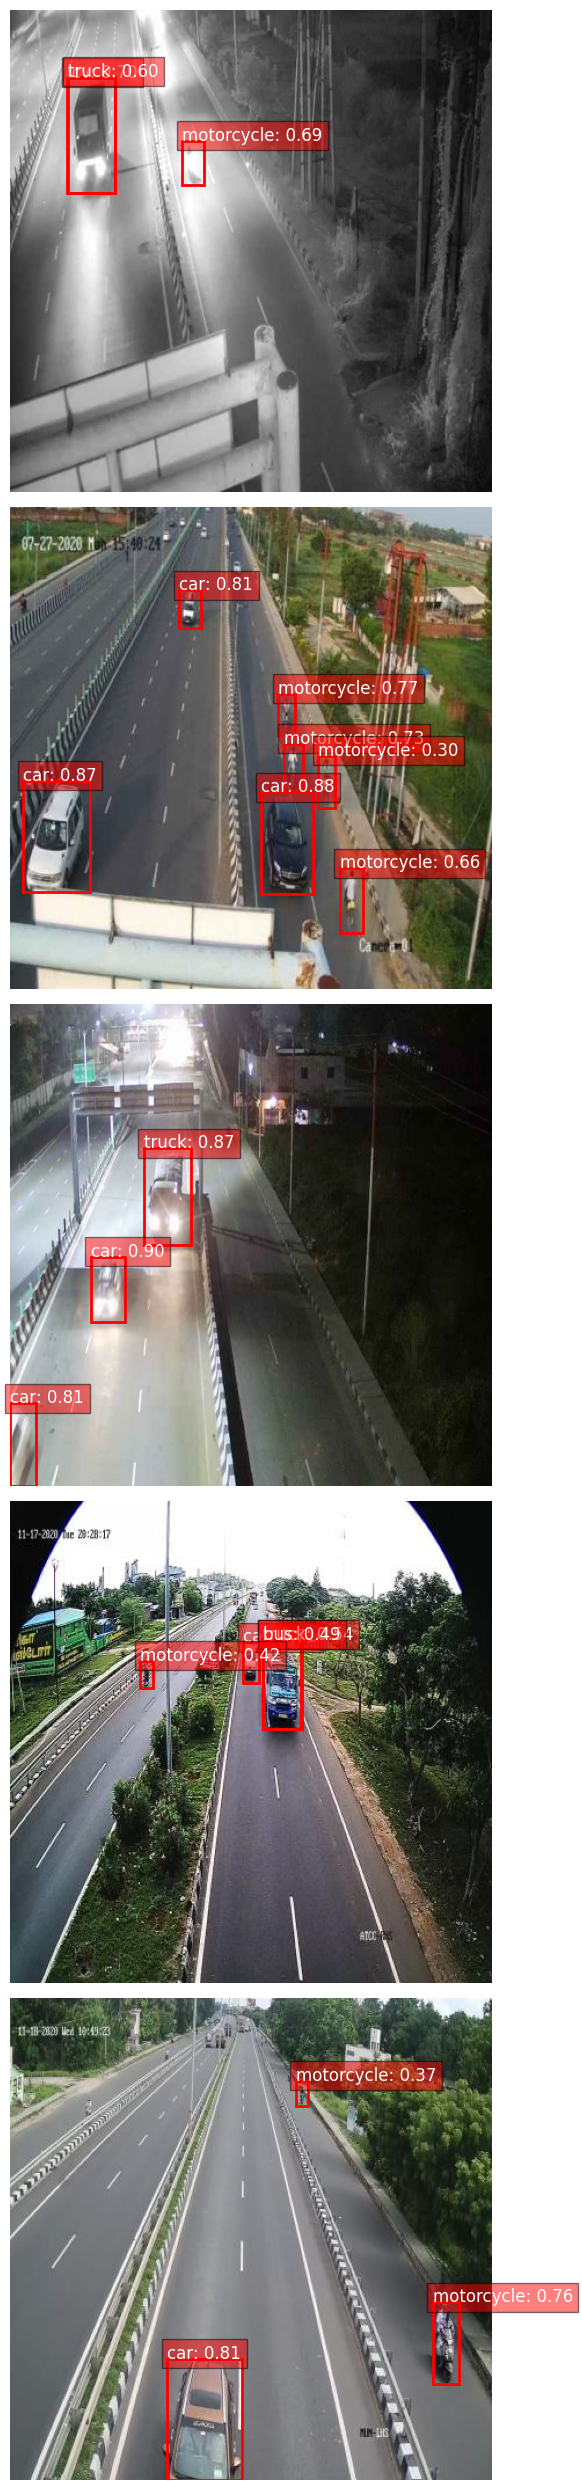

In [9]:
model = YOLO('/kaggle/working/runs/detect/vehicle-detection/yolov8n-8classes/weights/last.pt')
test_image_dir = '/kaggle/working/dataset/test/images'
test_images = os.listdir(test_image_dir)
test_images = [img for img in test_images if img.endswith('.jpg')]
sample_images = random.sample(test_images, 5)

fig, axes = plt.subplots(len(sample_images), 1, figsize=(10, len(sample_images) * 5))

for i, image_name in enumerate(sample_images):
    image_path = os.path.join(test_image_dir, image_name)
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = model(image_path)
    axes[i].imshow(img_rgb)
    axes[i].axis('off')
    
    for pred in results[0].boxes:
        x1, y1, x2, y2 = pred.xyxy[0].cpu().numpy()
        conf = float(pred.conf.cpu().numpy())
        class_id = int(pred.cls.cpu().numpy())
        label = model.names[class_id]
        
        axes[i].add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='red', linewidth=2))
        axes[i].text(x1, y1, f'{label}: {conf:.2f}', color='white', fontsize=12, bbox=dict(facecolor='red', alpha=0.5))

plt.tight_layout()
plt.show()


In [10]:
# Evaluate the model on the test set
results = model.val(
    data='/kaggle/working/dataset/data.yaml',  # path to your YAML file
    batch=16,                                 # batch size for evaluation
    imgsz=640,                                # image size used for evaluation
)

# The results object contains all the metrics
print("Precision:", results.metrics['precision'])
print("Recall:", results.metrics['recall'])
print("mAP@0.5:", results.metrics['mAP_0.5'])
print("mAP@0.5:0.95:", results.metrics['mAP_0.5:0.95'])


Ultralytics 8.4.9 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 931.2±322.4 MB/s, size: 26.9 KB)
val: Scanning /kaggle/working/dataset/test/labels.cache... 1644 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1644/1644 328.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 103/103 7.3it/s 14.1s0.1s
                   all       1644       5127      0.731      0.811      0.823      0.581
                  auto        130        152      0.716      0.868       0.81      0.514
                   bus        224        234      0.782      0.815       0.85      0.642
                   car       1152       2213      0.872      0.906      0.945      0.666
                   lcv        193        198      0.613      0.606      0.664      0.494
            motorcycle        808       1440      0.787      0.816      0.872      0.469
             multiaxle        22

AttributeError: 'DetMetrics' object has no attribute 'metrics'. See valid attributes below.
Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP).

    Attributes:
        names (dict[int, str]): A dictionary of class names.
        box (Metric): An instance of the Metric class for storing detection results.
        speed (dict[str, float]): A dictionary for storing execution times of different parts of the detection process.
        task (str): The task type, set to 'detect'.
        stats (dict[str, list]): A dictionary containing lists for true positives, confidence scores, predicted classes,
            target classes, and target images.
        nt_per_class: Number of targets per class.
        nt_per_image: Number of targets per image.

    Methods:
        update_stats: Update statistics by appending new values to existing stat collections.
        process: Process predicted results for object detection and update metrics.
    